## makemore: becoming a backprop ninja

swole doge style

In [1]:
# there no change change in the first several cells from last lecture

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42) # 设置随机种子，确保每次的各种集是相等的
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# ok biolerplate done, now we get to the action:

In [6]:
# 用于对比手动计算的梯度（manual gradient）和 PyTorch 自动计算的梯度是否一致。
def cmp(s, dt, t):  # (名称标签，手动计算的梯度， pytorch自动计算的梯度)
  ex = torch.all(dt == t.grad).item()  # 是否完全精确相等
  app = torch.allclose(dt, t.grad)     # 是否近似相等（考虑浮点误差）
  maxdiff = (dt - t.grad).abs().max().item()   # 最大绝对误差
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [7]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [8]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [9]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation

# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)  # 计算每个特征的均值
bndiff = hprebn - bnmeani  # 每个元素进行中心化
bndiff2 = bndiff**2  # 用于计算方差
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # 方差
bnvar_inv = (bnvar + 1e-5)**-0.5  # 标准差的倒数
bnraw = bndiff * bnvar_inv   # 将特征属性标准化
hpreact = bngain * bnraw + bnbias  # 预激活值标准化的结果后进行偏移和缩放

# Non-linearity
h = torch.tanh(hpreact) # 非线性激活

# Linear layer 2
logits = h @ W2 + b2 # output layer

# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values  
norm_logits = logits - logit_maxes # 防止数据溢出
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()
print(loss)

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3371, grad_fn=<NegBackward0>)


tensor(3.3371, grad_fn=<NegBackward0>)


### 第一阶段：交叉熵与 Softmax（从 Loss 倒推回原始分数 Logits）

这一段的本质，是把最终的亏损（Loss），分摊给每一个类别的预测概率和分子分母。

| 前向传播（Forward） | 反向传播（Backward） | 这个梯度的真正大白话意思 |
| --- | --- | --- |
| `loss = -logprobs[range(n), Yb].mean()` | `dlogprobs = torch.zeros_like(logprobs)` <br>

<br> `dlogprobs[range(n), Yb] = -1.0/n` | **对数概率的梯度**：因为算平均分时只挑了正确答案，所以错误答案的位置没参与，梯度为 0；正确答案的位置平摊了负均值责任，填入 $-1/n$。 |
| `logprobs = probs.log()` | `dprobs = (1.0 / probs) * dlogprobs` | **概率的梯度**：根据 $(\ln x)' = 1/x$ 传回。这里成功拉开贫富差距：**模型预测得越烂（`probs`越小），分子越大，最终梯度（怨念）就被放大越多个倍数。** |
| `probs = counts * counts_sum_inv` | `dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)` | **分母倒数的梯度**：前向是乘法，反向乘以对方。因为分母倒数在前向时横向广播（复制）给了所有类别，所以反向要把所有类别传回的梯度横向累加（`.sum(1)`）。 |
| （同上，对另一个乘数求导） | `dcounts = counts_sum_inv * dprobs` | **分子指数的梯度（第一部分）**：乘法求导，等于上游梯度乘以另一个乘数 `counts_sum_inv`。 |
| `counts_sum_inv = counts_sum**-1` | `dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv` | **分母和的梯度**：前向是求倒数 $x^{-1}$，根据数学公式 $(x^{-1})' = -1/x^2$，算出分母和应该承担的梯度。 |
| `counts_sum = counts.sum(1, keepdims=True)` | `dcounts += torch.ones_like(counts) * dcounts_sum` | **分子指数的梯度（第二部分合流）**：前向是求和，反向就是把梯度复制给每一个分支。因为 `dcounts` 之前有条路已经传过一次梯度了，所以用 `+=` 汇合。 |
| `counts = norm_logits.exp()` | `dnorm_logits = counts * dcounts` | **安全分数的梯度**：前向是指数函数 $e^x$，它的导数还是它自己（即 `counts`），所以直接乘以 `counts`。 |
| `norm_logits = logits - logit_maxes` | `dlogits = dnorm_logits.clone()` | **原始分数的梯度（第一部分）**：减法求导。对被减数 `logits` 的导数是 1，所以直接克隆上游梯度。 |
| （同上） | `dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)` | **每行最大值的梯度**：对减数的导数是 -1。因为最大值在前向时广播减给了所有人，反向必须纵向要求和（`.sum(1)`）收拢。 |
| `logit_maxes = logits.max(...)` | `dlogits += F.one_hot(...) * dlogit_maxes` | **原始分数的梯度（终极合流）**：前向的 `max` 只有最大值通关。反向用 one_hot 找到最大值对应的那个格子，把梯度单点注入进去，并通过 `+=` 和第一部分合流。 |

---

### 第二阶段：输出层全连接与激活函数

| 前向传播（Forward） | 反向传播（Backward） | 这个梯度的真正大白话意思 |
| --- | --- | --- |
| `logits = h @ W2 + b2` | `dh = dlogits @ W2.T` | **隐藏层激活值的梯度**：矩阵乘法求导，等于上游梯度乘以矩阵右边的转置 $W_2^T$。 |
| （同上） | `dW2 = h.T @ dlogits` | **输出层权重的梯度**：等于矩阵左边的转置 $h^T$ 乘以 `dlogits`。 |
| （同上） | `db2 = dlogits.sum(0)` | **输出层偏置的梯度**：偏置在所有样本间共享（广播），反向要把所有样本的梯度纵向累加（`.sum(0)`）。 |
| `h = torch.tanh(hpreact)` | `dhpreact = (1.0 - h**2) * dh` | **预激活值的梯度**：双曲正切 $\tanh(x)$ 的数学导数是 $1-\tanh^2(x)$，因为前向算出来的结果就叫 `h`，所以直接用 `1.0 - h**2` 过滤梯度。 |

---

### 第三阶段：大魔王 BatchNorm 层的逆向拆解

这一段是整段代码最恶心的地方，但记住：**它只是在用代码一步步硬解高数里“方差和标准差”的求导公式。**

| 前向传播（Forward） | 反向传播（Backward） | 这个梯度的真正大白话意思 |
| --- | --- | --- |
| `hpreact = bngain * bnraw + bnbias` | `dbngain = (bnraw * dhpreact).sum(0, keepdim=True)` | **缩放尺度 $\gamma$ 的梯度**：乘法求导加上跨样本求和（因为它也是跨 Batch 共享的）。 |
| （同上） | `dbnraw = bngain * dhpreact` | **未缩放归一化值的梯度**：乘法求导，上游梯度乘以倍率 `bngain`。 |
| （同上） | `dbnbias = dhpreact.sum(0, keepdim=True)` | **平移偏置 $\beta$ 的梯度**：加法求导加跨样本求和。 |
| `bnraw = bndiff * bnvar_inv` | `dbndiff = bnvar_inv * dbnraw` | **偏离均值距离的梯度（第一部分）**：乘法求导。 |
| （同上） | `dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)` | **标准差倒数的梯度**：乘法求导。因为标准差倒数是跨 Batch 算出来的，反向必须用 `.sum(0)`。 |
| `bnvar_inv = (bnvar + 1e-5)**-0.5` | `dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv` | **方差的梯度**：前向是幂函数 $x^{-0.5}$，根据高数公式 $(x^n)' = n \cdot x^{n-1}$，求导得到 $-0.5 \cdot x^{-1.5}$。 |
| `bnvar = 1/(n-1) * bndiff2.sum(0)` | `dbndiff2 = (1.0/(n-1))*ones_like... * dbnvar` | **平方距离的梯度**：前向是求和除以 $n-1$，反向就是原封不动乘上系数 $1/(n-1)$ 并复制广播回去。 |
| `bndiff2 = bndiff**2` | `dbndiff += (2*bndiff) * dbndiff2` | **偏离均值距离的梯度（第二部分合流）**：前向是平方 $x^2$，求导是 $2x$（即 `2*bndiff`）。两条路的梯度在此通过 `+=` 胜利会师！ |
| `bndiff = hprebn - bnmeani` | `dhprebn = dbndiff.clone()` | **输入值的梯度（第一部分）**：减法求导，对被减数的导数是 1。 |
| （同上） | `dbnmeani = (-dbndiff).sum(0)` | **均值的梯度**：对减数的导数是 -1。因为均值跨 Batch 共享，反向用 `.sum(0)`。 |
| `bnmeani = 1/n * hprebn.sum(0)` | `dhprebn += 1.0/n * (ones_like... * dbnmeani)` | **输入值的梯度（第二部分合流）**：把均值那条路分摊的梯度（除以 $n$）用 `+=` 重新加回到输入值上。 |

---

### 第四阶段：回溯到最底层的词嵌入（Embedding）

| 前向传播（Forward） | 反向传播（Backward） | 这个梯度的真正大白话意思 |
| --- | --- | --- |
| `hprebn = embcat @ W1 + b1` | `dembcat = dhprebn @ W1.T` <br>

<br> `dW1 = embcat.T @ dhprebn` <br>

<br> `db1 = dhprebn.sum(0)` | **第一层全连接的求导**：这三行和上面的第二阶段（`W2, b2`）长得一模一样，纯粹的矩阵乘法求导复制。 |
| `embcat = demb.view(shape)` | `demb = dembcat.view(emb.shape)` | **重塑形状的梯度**：前向把高维矩阵压扁，反向只需要用 `.view` 把梯度重新揉圆、塞回原本的坑位里。 |
| `emb = C[Xb]` | `dC = torch.zeros_like(C)` <br>

<br> `for... dC[ix] += demb[k,j]` | **词向量查找表的梯度**：前向是通过索引 `Xb` 去大字典 `C` 里“查表”。因为同一个字在前向时被反复调用，反向时这些分身在外面受到的所有梯度，**必须用 `+=` 狠狠地全部累加回字典的同一行（`ix`）里**。 |

---

### 💡 核心心法总结

1. **为什么总有 `.sum()`？** 只要前向传播里发生了“多对一”（比如几百个样本求和算出了一个均值，或者一个数字被复制给了几百个通道），反向传播时，那几百个通道传回来的梯度，就必须用 **`.sum()`** 重新揉成一个数字。
2. **为什么总有 `+=`？**
只要前向传播里一个变量**分叉走两条路**参与了计算，反向传播时，两条路传回来的梯度就绝对不能直接覆盖，必须用 **`+=`** 进行累加。

配合这张对照表，把它当成一份“逆向走迷宫”的地图，每次看代码卡壳时就来查一下这一行的前向是谁，是不是感觉心里有底多了？

In [10]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one

# 交叉熵与 Softmax
dlogprobs = torch.zeros_like(logprobs) # loss = -logprobs[range(n), Yb].mean()
dlogprobs[range(n), Yb] = -1.0/n  # 
#概率的梯度：根据 (ln x)' = 1/x 传回。这里成功拉开贫富差距：模型预测得越烂（probs越小），分子越大，最终梯度（怨念）就被放大越多个倍数。
dprobs = (1.0 / probs) * dlogprobs # logprobs = probs.log()
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)   # probs = counts * counts_sum_inv
dcounts = counts_sum_inv * dprobs  
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv   # counts_sum_inv = counts_sum**-1
dcounts += torch.ones_like(counts) * dcounts_sum   # counts_sum = counts.sum(1, keepdims=True)
dnorm_logits = counts * dcounts    # counts = norm_logits.exp()
dlogits = dnorm_logits.clone()   # norm_logits = logits - logit_maxes
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes # logit_maxes = logits.max(...)

# 输出全连接和激活函数
dh = dlogits @ W2.T  # logits = h @ W2 + b2
dW2 = h.T @ dlogits  # 
db2 = dlogits.sum(0)
dhpreact = (1.0 - h**2) * dh # h = torch.tanh(hpreact)

# BatchNorm 层的逆向拆解
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)   # hpreact = bngain * bnraw + bnbias
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True)
dbndiff = bnvar_inv * dbnraw    # bnraw = bndiff * bnvar_inv
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)  
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv  # bnvar_inv = (bnvar + 1e-5)**-0.5
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar  # bnvar = 1/(n-1) * bndiff2.sum(0)
dbndiff += (2*bndiff) * dbndiff2   # bndiff2 = bndiff**2
dhprebn = dbndiff.clone()  #  bndiff = hprebn - bnmeani
dbnmeani = (-dbndiff).sum(0)  
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)  # bnmeani = 1/n * hprebn.sum(0)

# 最底层的词嵌入
dembcat = dhprebn @ W1.T  # hprebn = embcat @ W1 + b1
dW1 = embcat.T @ dhprebn  
db1 = dhprebn.sum(0)
demb = dembcat.view(emb.shape)  # embcat = demb.view(shape)

dC = torch.zeros_like(C)  # emb = C[Xb]
for k in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix = Xb[k,j]
    dC[ix] += demb[k,j]
    
cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

In [211]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.3377387523651123 diff: 2.384185791015625e-07


In [11]:
# backward pass

dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 6.984919309616089e-09


In [12]:
logits.shape, Yb.shape

(torch.Size([32, 27]), torch.Size([32]))

In [13]:
F.softmax(logits, 1)[0]

tensor([0.0660, 0.0925, 0.0167, 0.0470, 0.0185, 0.0848, 0.0245, 0.0364, 0.0169,
        0.0327, 0.0364, 0.0368, 0.0354, 0.0283, 0.0340, 0.0128, 0.0087, 0.0191,
        0.0160, 0.0548, 0.0483, 0.0225, 0.0265, 0.0739, 0.0608, 0.0265, 0.0230],
       grad_fn=<SelectBackward0>)

In [14]:
dlogits[0] * n

tensor([ 0.0660,  0.0925,  0.0167,  0.0470,  0.0185,  0.0848,  0.0245,  0.0364,
        -0.9831,  0.0327,  0.0364,  0.0368,  0.0354,  0.0283,  0.0340,  0.0128,
         0.0087,  0.0191,  0.0160,  0.0548,  0.0483,  0.0225,  0.0265,  0.0739,
         0.0608,  0.0265,  0.0230], grad_fn=<MulBackward0>)

In [15]:
dlogits[0].sum()

tensor(-1.3970e-09, grad_fn=<SumBackward0>)

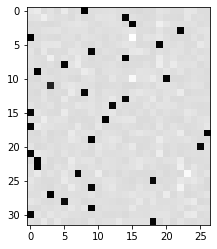

In [239]:
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach(), cmap='gray')

In [16]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [279]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [278]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, dbnraw.shape, dbnraw.sum(0).shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([64]))

In [17]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():

  # kick off optimization
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
      p.grad = None
    #loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # -----------------
    dlogits = F.softmax(logits, 1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n
    # 2nd layer backprop
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    # tanh
    dhpreact = (1.0 - h**2) * dh
    # batchnorm backprop
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    # 1st layer
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    # embedding
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      #p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

  #   if i >= 100: # TODO: delete early breaking when you're ready to train the full net
  #     break

12297
      0/ 200000: 3.7408
  10000/ 200000: 2.1405
  20000/ 200000: 2.3962
  30000/ 200000: 2.4298
  40000/ 200000: 1.9984
  50000/ 200000: 2.4350
  60000/ 200000: 2.3853
  70000/ 200000: 2.0415
  80000/ 200000: 2.4015
  90000/ 200000: 2.1418
 100000/ 200000: 1.9267
 110000/ 200000: 2.3827
 120000/ 200000: 2.0242
 130000/ 200000: 2.4529
 140000/ 200000: 2.2700
 150000/ 200000: 2.1337
 160000/ 200000: 2.0240
 170000/ 200000: 1.8782
 180000/ 200000: 2.0184
 190000/ 200000: 1.8863


In [285]:
# useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

In [19]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)  # 对整个数据集求均值，每个隐藏神经元统计一个平均值
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)  # 方差


In [20]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0727992057800293
val 2.1122610569000244


In [294]:
# I achieved:
# train 2.0718822479248047
# val 2.1162495613098145

In [40]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # ------------
      # forward pass:
      # Embedding
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # ------------
      # Sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

mora.
mayah.
see.
mad.
ryla.
reisha.
endraegan.
chedielin.
shi.
jen.
eden.
estanar.
kayzion.
kamin.
shubergihiriel.
kin.
renlynn.
novana.
ubmeyce.
ryyah.
